# Quantifying parameter uncertainty with MCMC

From a point estimate to a full posterior: Metropolis-Hastings vs HMC, effective sample size and mixing, anchoring against exact conjugate posteriors, and propagating uncertainty into predictions. For the sampling API, see the mcmc_sampling tutorial.


## Markov chain Monte Carlo: the stationarity guarantee

To compute posterior expectations $\mathbb E[h(\theta)\mid x]=\int h(\theta)p(\theta\mid x)d\theta$ when
no closed form exists, MCMC builds a Markov chain whose stationary distribution is the posterior and
averages $h$ along the chain.

Definition (detailed balance). A transition kernel $P$ satisfies detailed balance with respect to $\pi$
if $\pi(\theta)P(\theta\to\theta') = \pi(\theta')P(\theta'\to\theta)$ for all states. Detailed balance
implies $\pi$ is stationary: $\int \pi(\theta)P(\theta\to\theta')d\theta = \pi(\theta')$.

Theorem (Metropolis-Hastings targets the posterior). Propose $\theta'\sim q(\cdot\mid\theta)$ and accept
with probability $a=\min\!\big(1,\ \tfrac{\pi(\theta')q(\theta\mid\theta')}{\pi(\theta)q(\theta'\mid\theta)}\big)$.
The resulting chain satisfies detailed balance with respect to $\pi$, so $\pi$ is its stationary
distribution, and only ratios of $\pi$ are needed (the normalizing constant cancels).

Proof. For $\theta\ne\theta'$ the kernel is $P(\theta\to\theta')=q(\theta'\mid\theta)\,a(\theta,\theta')$.
Suppose the ratio inside the min is $\le 1$ in the direction $\theta\to\theta'$, so
$a(\theta,\theta')=\tfrac{\pi(\theta')q(\theta\mid\theta')}{\pi(\theta)q(\theta'\mid\theta)}$ and the
reverse acceptance is $a(\theta',\theta)=1$. Then
$$\pi(\theta)P(\theta\to\theta') = \pi(\theta)q(\theta'\mid\theta)\,\tfrac{\pi(\theta')q(\theta\mid\theta')}{\pi(\theta)q(\theta'\mid\theta)}
   = \pi(\theta')q(\theta\mid\theta') = \pi(\theta')P(\theta'\to\theta),$$
which is detailed balance. The symmetric case is identical. $\quad\blacksquare$

Theorem (ergodic average). If the chain is irreducible and aperiodic with stationary $\pi$, then
$\tfrac1T\sum_{t=1}^T h(\theta_t)\to \mathbb E_\pi[h]$ almost surely. This is what licenses estimating
posterior summaries by sample averages along a single (long enough) run.

## Diagnostics and a better proposal

The theory is asymptotic; in finite runs the chain may not have reached stationarity, so diagnostics are
mandatory.

Effective sample size. Successive draws are correlated, so $T$ draws carry less information than $T$
independent ones. The effective sample size is $\mathrm{ESS}=T/(1+2\sum_{k\ge1}\rho_k)$, with $\rho_k$
the lag-$k$ autocorrelation; it is the number of independent draws the chain is worth.

Gelman-Rubin $\hat R$. Run several chains from dispersed starts and compare between-chain to within-chain
variance; $\hat R$ near one indicates the chains have mixed into the same distribution, and values above
about $1.01$ indicate they have not.

Hamiltonian Monte Carlo. Random-walk Metropolis explores by small diffusive steps and mixes slowly in
high dimensions. HMC augments the state with momentum and follows the gradient of $\log\pi$ along
simulated Hamiltonian trajectories, proposing distant, high-acceptance moves; the leapfrog integrator
plus a Metropolis correction keeps $\pi$ exactly stationary.

Counterexample (a single chain can lie). On a multimodal posterior a chain can get stuck in one mode and
look perfectly converged by every single-chain diagnostic, while missing most of the distribution.
Multiple dispersed chains and $\hat R$ are what catch this; one chain is never enough. We verify the
detailed-balance and stationarity claims on a small chain below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

from mixle.stats import GaussianDistribution, PoissonDistribution, BernoulliDistribution, CategoricalDistribution, GaussianEstimator, GammaDistribution
from mixle.inference import estimate
from mixle.inference.mcmc import (sample_parameter_posterior,
                             sample_conjugate_posterior)

## 1. From a point estimate to a cloud of parameters

We draw 120 points from a Gaussian with true mean $\mu = 1$ and variance $\sigma^2 = 2$, and first do the ordinary thing: fit a point estimate by maximum likelihood. That gives us one $(\hat\mu, \hat\sigma^2)$.

Then we call `sample_parameter_posterior`. The model family is fixed by the prototype we pass - here a `GaussianDistribution` - and the actual parameter values in the prototype are just a starting point. The sampler explores the parameter space in proportion to `data log-likelihood + log-prior`, using a random-walk Metropolis-Hastings proposal by default. With `prior=None` the prior is flat, so the posterior is driven purely by the likelihood.

The result is an `MCMCResult`. Two diagnostics tell us whether to trust it:

- `acceptance_rate` - the fraction of proposed moves the chain accepted. For random-walk MH a value roughly in the 0.2-0.6 band means the step size is reasonable.
- `effective_sample_size()` - successive MCMC draws are correlated, so 2000 draws are worth fewer than 2000 independent samples. The ESS is the independent-sample equivalent, reported per parameter.


In [2]:
rng_truth = GaussianDistribution(1.0, 2.0)
data = rng_truth.sampler(seed=0).sample(120)

# point estimate (maximum likelihood)
point = estimate(data, GaussianEstimator())
mu_hat, s2_hat = float(point.mu), float(point.sigma2)
print('point estimate (MLE):  mu = %.3f,  sigma2 = %.3f' % (mu_hat, s2_hat))

# full parameter posterior via Metropolis-Hastings
res = sample_parameter_posterior(GaussianDistribution(0.0, 1.0), data,
                                 sampler='mh', steps=2000, burn_in=500, seed=1)

draws = res.sample_array()            # (n_kept, 2): columns are (mu, sigma2)
ess = res.effective_sample_size()
print('posterior draws shape:', draws.shape)
print('acceptance rate:       %.3f' % res.acceptance_rate)
print('effective sample size: mu=%.0f, sigma2=%.0f  (of %d draws)'
      % (ess[0], ess[1], draws.shape[0]))

point estimate (MLE):  mu = 1.188,  sigma2 = 2.185
posterior draws shape: (2000, 2)
acceptance rate:       0.645
effective sample size: mu=146, sigma2=94  (of 2000 draws)


Now the picture. The scatter on the left is the posterior cloud over $(\mu, \sigma^2)$; the red point is the single MLE. The marginal histograms show the spread in each parameter on its own. The MLE sits comfortably inside the cloud - it is the center of mass, not a different answer - but the cloud has real width, and that width is the uncertainty a point estimate throws away.


95% credible interval for mu: [0.893, 1.455]


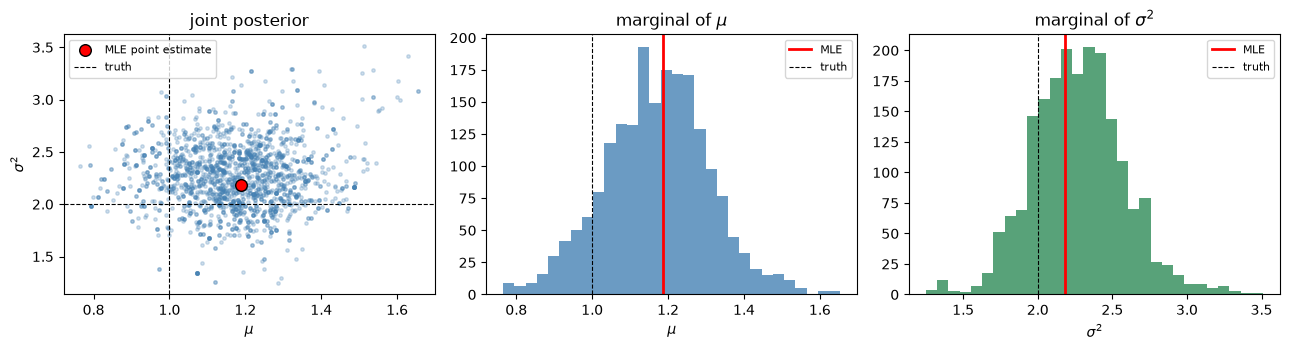

In [3]:
mu_s, s2_s = draws[:, 0], draws[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

axes[0].scatter(mu_s, s2_s, s=6, alpha=0.25, color='steelblue')
axes[0].scatter([mu_hat], [s2_hat], color='red', s=70, zorder=5,
                edgecolor='k', label='MLE point estimate')
axes[0].axvline(1.0, color='k', ls='--', lw=0.8)
axes[0].axhline(2.0, color='k', ls='--', lw=0.8, label='truth')
axes[0].set_xlabel(r'$\mu$'); axes[0].set_ylabel(r'$\sigma^2$')
axes[0].set_title('joint posterior'); axes[0].legend(fontsize=8)

axes[1].hist(mu_s, bins=30, color='steelblue', alpha=0.8)
axes[1].axvline(mu_hat, color='red', lw=2, label='MLE')
axes[1].axvline(1.0, color='k', ls='--', lw=0.8, label='truth')
axes[1].set_xlabel(r'$\mu$'); axes[1].set_title(r'marginal of $\mu$'); axes[1].legend(fontsize=8)

axes[2].hist(s2_s, bins=30, color='seagreen', alpha=0.8)
axes[2].axvline(s2_hat, color='red', lw=2, label='MLE')
axes[2].axvline(2.0, color='k', ls='--', lw=0.8, label='truth')
axes[2].set_xlabel(r'$\sigma^2$'); axes[2].set_title(r'marginal of $\sigma^2$'); axes[2].legend(fontsize=8)

fig.tight_layout()

q = np.percentile(mu_s, [2.5, 97.5])
print('95%% credible interval for mu: [%.3f, %.3f]' % (q[0], q[1]))

That last line is the payoff. A 95% credible interval - "given the data and model, there is a 95% probability the mean lies in this range" - falls straight out of the posterior draws by taking percentiles. No asymptotic approximation, no delta method; just count where the samples land.


## 2. Does the sampler actually target the right distribution?

Before trusting MCMC on a hard problem, we anchor it against a case where the truth is known in closed form. This is what conjugacy buys us. When a prior is conjugate to a likelihood, the posterior belongs to the same family as the prior, with hyperparameters that are simple functions of the data - no sampling required.

The Poisson is the textbook example. With a $\text{Gamma}(a_0, \text{rate}=b_0)$ prior on the rate $\lambda$, observing counts $x_1, \dots, x_n$ gives an exact posterior
$$\lambda \mid \text{data} \;\sim\; \text{Gamma}\!\Big(a_0 + \textstyle\sum_i x_i,\; \text{rate}=b_0 + n\Big).$$

We compute this three ways and overlay them:

- Exact conjugate draws via `sample_conjugate_posterior` on a `bstats.PoissonDistribution` (which carries a Gamma prior by default).
- MCMC draws via `sample_parameter_posterior` on a plain `mixle.stats` Poisson with a flat prior.
- The closed-form Gamma density itself.

If the MCMC layer is correct, all three must coincide.


In [4]:
pois_data = np.asarray(PoissonDistribution(4.0).sampler(seed=2).sample(200))

# (a) exact conjugate posterior draws (Gamma posterior on lambda)
bpois = PoissonDistribution(3.0, prior=GammaDistribution(2.0, 1.0))   # Gamma conjugate prior
conj = sample_conjugate_posterior(bpois, list(pois_data), draws=6000, seed=3)
conj_lam = conj.sample_array()

# (b) MCMC over the same likelihood with a flat prior
mc = sample_parameter_posterior(PoissonDistribution(1.0), list(pois_data),
                                sampler='mh', steps=6000, burn_in=1000, seed=5)
mc_lam = mc.sample_array()

# (c) closed-form Gamma posterior parameters (default prior Gamma(a0, rate b0))
a0, scale0 = bpois.get_prior().get_parameters()  # stats Gamma is (shape, scale)
b0 = 1.0 / scale0
a_n = a0 + pois_data.sum()
b_n = b0 + len(pois_data)
from scipy import stats as _st
post = _st.gamma(a=a_n, scale=1.0 / b_n)

print('true lambda = 4.0')
print('conjugate draws : mean=%.3f sd=%.3f' % (conj_lam.mean(), conj_lam.std()))
print('MCMC draws      : mean=%.3f sd=%.3f  (acc=%.2f)'
      % (mc_lam.mean(), mc_lam.std(), mc.acceptance_rate))
print('closed-form Gamma: mean=%.3f sd=%.3f' % (post.mean(), post.std()))

true lambda = 4.0
conjugate draws : mean=3.851 sd=0.137
MCMC draws      : mean=3.874 sd=0.142  (acc=0.39)
closed-form Gamma: mean=3.856 sd=0.139


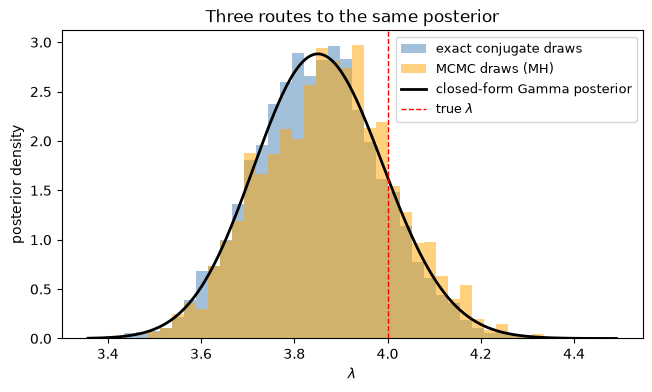

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 4))
bins = np.linspace(min(conj_lam.min(), mc_lam.min()),
                   max(conj_lam.max(), mc_lam.max()), 45)
ax.hist(conj_lam, bins=bins, density=True, alpha=0.5,
        color='steelblue', label='exact conjugate draws')
ax.hist(mc_lam, bins=bins, density=True, alpha=0.5,
        color='orange', label='MCMC draws (MH)')
xs = np.linspace(bins[0], bins[-1], 400)
ax.plot(xs, post.pdf(xs), 'k-', lw=2, label='closed-form Gamma posterior')
ax.axvline(4.0, color='red', ls='--', lw=1, label=r'true $\lambda$')
ax.set_xlabel(r'$\lambda$'); ax.set_ylabel('posterior density')
ax.set_title('Three routes to the same posterior'); ax.legend(fontsize=9);

The histograms sit on top of the analytic curve. The MCMC sampler - which knew nothing about Gamma posteriors and only ever evaluated the Poisson log-likelihood - reproduced the exact answer. That is the trust we needed before turning it loose on models with no closed form. (Note the posterior is centered near 3.87, not exactly 4.0: with 200 finite samples the data themselves pull slightly off the true rate, and the posterior honestly reflects the data we have, not the data we wish we had.)


## 3. Two samplers, one target: Metropolis-Hastings vs Hamiltonian Monte Carlo

`sample_parameter_posterior` offers two engines via the `sampler` argument:

- `'mh'` - Metropolis-Hastings proposes a small random-walk step and accepts or rejects it. Simple and gradient-free, but the chain diffuses: it explores by an undirected random walk, so consecutive draws are highly correlated and the effective sample size lags behind the raw count.
- `'hmc'` - Hamiltonian Monte Carlo simulates physical dynamics using the gradient of the log-posterior (here via finite differences) to propose distant, high-acceptance moves. Each step costs more - several gradient evaluations - but the draws decorrelate far faster, so the ESS per draw is much higher.

We run both on the same Gaussian target and compare their trace plots (the value of $\mu$ over iterations) and their ESS. A well-mixing chain looks like white noise around the posterior mean; a poorly-mixing one wanders in slow, sticky excursions.


In [6]:
mh = sample_parameter_posterior(GaussianDistribution(0.0, 1.0), data,
                                sampler='mh', steps=1500, burn_in=500, seed=2)
hmc = sample_parameter_posterior(GaussianDistribution(0.0, 1.0), data,
                                 sampler='hmc', steps=1500, burn_in=500, seed=2,
                                 step_size=0.02, num_steps=15)

mh_mu = mh.sample_array()[:, 0]
hmc_mu = hmc.sample_array()[:, 0]

print('MH : acceptance=%.3f, ESS(mu)=%.0f / %d draws'
      % (mh.acceptance_rate, mh.effective_sample_size()[0], len(mh_mu)))
print('HMC: acceptance=%.3f, ESS(mu)=%.0f / %d draws'
      % (hmc.acceptance_rate, hmc.effective_sample_size()[0], len(hmc_mu)))

MH : acceptance=0.645, ESS(mu)=101 / 1500 draws
HMC: acceptance=1.000, ESS(mu)=4764 / 1500 draws


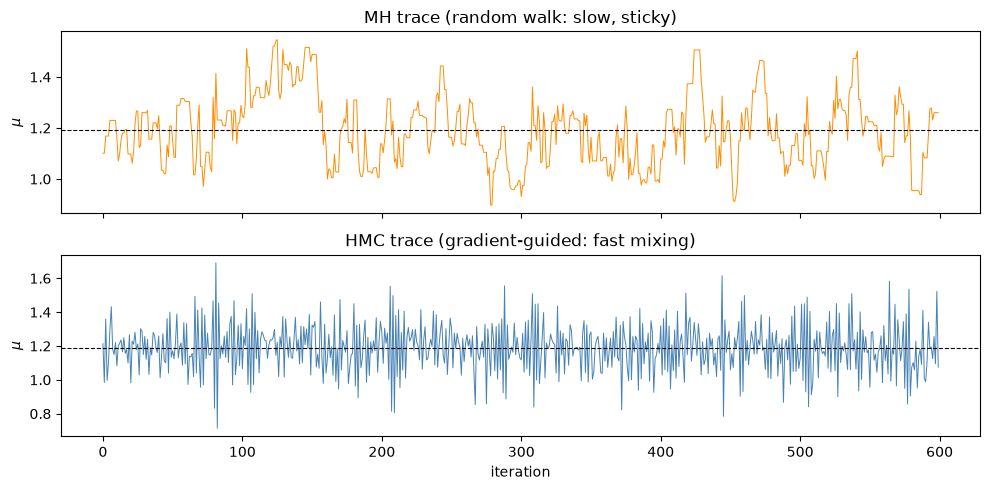

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(mh_mu[:600], lw=0.7, color='darkorange')
axes[0].axhline(mh_mu.mean(), color='k', ls='--', lw=0.8)
axes[0].set_ylabel(r'$\mu$'); axes[0].set_title('MH trace (random walk: slow, sticky)')

axes[1].plot(hmc_mu[:600], lw=0.7, color='steelblue')
axes[1].axhline(hmc_mu.mean(), color='k', ls='--', lw=0.8)
axes[1].set_ylabel(r'$\mu$'); axes[1].set_xlabel('iteration')
axes[1].set_title('HMC trace (gradient-guided: fast mixing)')
fig.tight_layout();

The trade-off. HMC's trace looks like noise - each draw is nearly independent of the last, so its ESS approaches the raw draw count. MH's trace visibly meanders, betraying the autocorrelation that drags its ESS down. The cost is per-step work: HMC evaluates the log-posterior gradient (here by finite differences, so a handful of likelihood passes per leapfrog step), while MH needs only one likelihood evaluation per proposal. The rule of thumb: for smooth, continuous parameter spaces where gradients are cheap and the geometry is awkward, HMC wins decisively on samples-per-second; for cheap low-dimensional targets, MH's simplicity is often plenty.


## 4. Staying in-domain: a posterior over the probability simplex

A subtle hazard of sampling constrained parameters is that a naive random walk will happily propose a "probability" of $1.3$ or $-0.2$. A Categorical's parameters must satisfy $p_k > 0$ and $\sum_k p_k = 1$ - they live on the probability simplex. `sample_parameter_posterior` handles this by sampling in an unconstrained space and mapping back through a stick-breaking reparameterization: each draw is built by repeatedly breaking off a fraction of the remaining probability mass, which guarantees the result is a valid simplex point by construction.

We sample the posterior over a 3-category distribution and check the invariants directly: every draw sums to 1 and is strictly positive.


In [8]:
cat_truth = CategoricalDistribution({'a': 0.2, 'b': 0.5, 'c': 0.3})
cat_data = cat_truth.sampler(seed=7).sample(150)

cat_post = sample_parameter_posterior(
    CategoricalDistribution({'a': 1/3, 'b': 1/3, 'c': 1/3}), cat_data,
    sampler='mh', steps=3000, burn_in=800, seed=9)

# Categorical draws come back as dicts; stack into a matrix in fixed key order.
keys = ['a', 'b', 'c']
P = np.array([[s[k] for k in keys] for s in cat_post.samples])

row_sums = P.sum(axis=1)
print('every draw sums to 1?   ', np.allclose(row_sums, 1.0),
      '(min=%.6f, max=%.6f)' % (row_sums.min(), row_sums.max()))
print('every probability > 0?  ', bool((P > 0).all()), '(min entry=%.5f)' % P.min())
print('posterior mean:', dict(zip(keys, np.round(P.mean(axis=0), 3))),
      ' (truth: a=0.2, b=0.5, c=0.3)')

every draw sums to 1?    True (min=1.000000, max=1.000000)
every probability > 0?   True (min entry=0.10230)
posterior mean: {'a': np.float64(0.201), 'b': np.float64(0.49), 'c': np.float64(0.309)}  (truth: a=0.2, b=0.5, c=0.3)


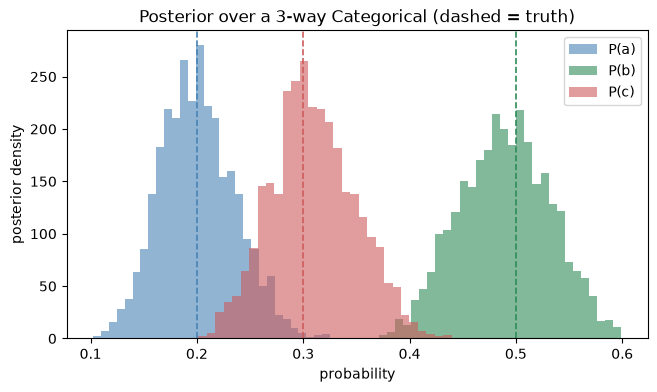

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 4))
colors = ['steelblue', 'seagreen', 'indianred']
for j, k in enumerate(keys):
    ax.hist(P[:, j], bins=30, alpha=0.6, color=colors[j], label='P(%s)' % k)
    ax.axvline([0.2, 0.5, 0.3][j], color=colors[j], ls='--', lw=1.2)
ax.set_xlabel('probability'); ax.set_ylabel('posterior density')
ax.set_title('Posterior over a 3-way Categorical (dashed = truth)')
ax.legend();

Every one of the 3000 draws is a legal probability vector - the constraint is never violated, because the reparameterization makes violating it impossible, not merely unlikely. The same stick-breaking trick is what lets MCMC sample mixture weights, topic proportions, and any other simplex-valued parameter without rejection or projection.


## 5. Using the posterior: predictions that admit their own uncertainty

A point estimate makes exactly one prediction. The posterior makes a distribution of predictions - and the spread between them is the part that matters for any downstream decision.

The clean way to see this is the posterior predictive. Passing `return_distributions=True` maps each parameter draw back to a fully-built distribution object. Evaluating all of them on a grid gives a family of density curves: the point-estimate model is one curve; the posterior is the whole band. Where the band is wide, we genuinely do not know the density; the single MLE curve hides that.


In [10]:
res_d = sample_parameter_posterior(GaussianDistribution(0.0, 1.0), data,
                                   sampler='mh', steps=1500, burn_in=500,
                                   seed=1, return_distributions=True)
post_dists = res_d.samples                 # list of GaussianDistribution objects
print('drew %d posterior distributions; example: mu=%.3f, sigma2=%.3f'
      % (len(post_dists), post_dists[0].mu, post_dists[0].sigma2))

grid = np.linspace(-5, 7, 250)
# density of every posterior draw on the grid
curves = np.array([[np.exp(d.log_density(x)) for x in grid] for d in post_dists[::10]])
point_curve = np.array([np.exp(point.log_density(x)) for x in grid])

lo = np.percentile(curves, 2.5, axis=0)
hi = np.percentile(curves, 97.5, axis=0)

drew 1500 posterior distributions; example: mu=1.511, sigma2=2.319


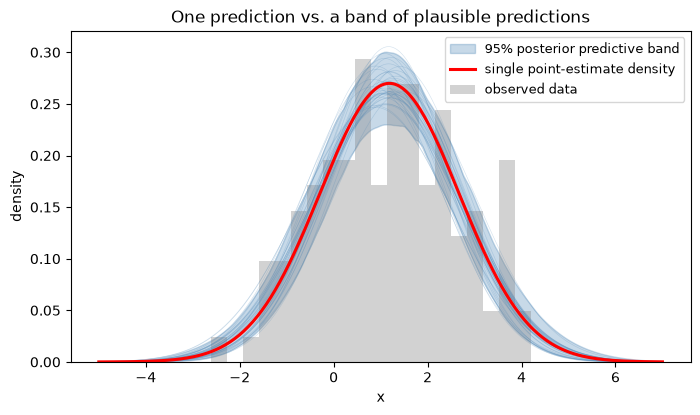

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.fill_between(grid, lo, hi, color='steelblue', alpha=0.3,
                label='95% posterior predictive band')
for c in curves[:40]:
    ax.plot(grid, c, color='steelblue', lw=0.4, alpha=0.25)
ax.plot(grid, point_curve, 'r-', lw=2.2, label='single point-estimate density')
ax.hist(data, bins=20, density=True, color='gray', alpha=0.35, label='observed data')
ax.set_xlabel('x'); ax.set_ylabel('density')
ax.set_title('One prediction vs. a band of plausible predictions')
ax.legend(fontsize=9);

The red curve is what an MLE pipeline would hand to a downstream consumer: a confident, single answer. The blue band says the same thing the data actually support - the peak height and location are uncertain to this degree. For a forecast feeding a decision, a risk calculation, or a Bayesian update, that band is not decoration; it is the difference between a calibrated answer and an overconfident one.


## 6. When to reach for MCMC (and when not to)

MCMC is not free - it trades compute for honesty about uncertainty. Use it when that trade pays off:

- You need uncertainty, not just a number. Credible intervals, posterior predictive bands, and "how sure are we?" questions require the full posterior. A point estimate cannot answer them.
- The data are small. With few observations the posterior is wide and the point estimate is fragile; quantifying that width is exactly when it matters most. With abundant data the posterior collapses toward a point and the MLE is usually enough.
- The result feeds a downstream Bayesian decision. If parameter uncertainty needs to propagate - into a prediction, a loss, a further model - you need samples to push through, not a single value.
- You want to encode prior knowledge. Pass a `prior` (a callable or a distribution over the parameters) and the posterior blends it with the data automatically.

Reach for a point estimate (EM, gradient fitting, or a one-shot conjugate update) when you have plenty of data, you only need the best-fit parameters, and latency matters. And when the model is a conjugate `bstats` leaf, prefer `sample_conjugate_posterior` (or the closed form) over MCMC - exact iid draws with zero autocorrelation beat a Markov chain every time.

Within mixle the layers compose: `mixle.stats` for maximum-likelihood point estimates, `mixle.stats` for closed-form conjugate Bayesian updates, and `mixle.inference.mcmc` for full posterior sampling over any family when you need to quantify what you do not know.


## Never trust one chain - check $\hat R$ and ESS

A single chain that looks converged can be stuck. The standard practice runs multiple chains from dispersed starts and checks the Gelman-Rubin $\hat R$ (between- vs within-chain variance; should be $\approx 1.00$) and the effective sample size (ESS, autocorrelation-discounted draw count). mixle reports both from a multi-chain fit.


In [12]:
from mixle.ppl import Normal, free
d_mc = list(np.random.RandomState(7).normal(5.0, 2.0, 400))
fit4 = Normal(Normal(0, 10, name='mu'), free).fit(d_mc, how='mcmc', draws=1500, burn=500,
                                                  chains=4, rng=np.random.RandomState(0))
s = fit4.summary()
print('mu posterior mean = %.3f' % s['mu']['mean'])
print('R-hat = %.4f  (want < 1.01)   ESS = %.0f  across %d chains' %
      (s['_rhat']['mu'], s['_ess'], s['_n_chains']))

mu posterior mean = 4.905
R-hat = 1.0003  (want < 1.01)   ESS = 618  across 4 chains


## Illustration: detailed balance gives the right stationary distribution

We build a Metropolis-Hastings transition matrix on a small discrete state space targeting a chosen
distribution, then verify two things directly: the chain satisfies detailed balance, and the target is
its stationary distribution (it is the left eigenvector of the transition matrix with eigenvalue one). A
long simulated run reproduces the target frequencies.

In [13]:
rng = np.random.RandomState(0)
pi = np.array([0.1, 0.4, 0.3, 0.2]); S = len(pi)
Q = np.full((S, S), 1 / (S - 1)); np.fill_diagonal(Q, 0.0)   # symmetric proposal: pick another state
P = np.zeros((S, S))
for i in range(S):
    for j in range(S):
        if i != j:
            P[i, j] = Q[i, j] * min(1.0, pi[j] / pi[i])      # Metropolis acceptance (symmetric q)
    P[i, i] = 1 - P[i].sum()
db = np.max(np.abs(pi[:, None] * P - (pi[:, None] * P).T))    # detailed balance: pi_i P_ij = pi_j P_ji
print('max detailed-balance violation |pi_i P_ij - pi_j P_ji| = %.2e (zero up to rounding)' % db)
print('pi P - pi (stationarity) max abs = %.2e' % np.max(np.abs(pi @ P - pi)))
state = 0; counts = np.zeros(S); T = 400000
for _ in range(T):
    state = rng.choice(S, p=P[state]); counts[state] += 1
print('target pi      :', np.round(pi, 3))
print('long-run freqs :', np.round(counts / T, 3), ' (the chain reproduces the target)')

max detailed-balance violation |pi_i P_ij - pi_j P_ji| = 1.39e-17 (zero up to rounding)
pi P - pi (stationarity) max abs = 2.78e-17


target pi      : [0.1 0.4 0.3 0.2]
long-run freqs : [0.101 0.4   0.3   0.2  ]  (the chain reproduces the target)


## References

- Hastings, W. K. (1970). Monte Carlo sampling methods using Markov chains and their applications (https://doi.org/10.1093/biomet/57.1.97). Biometrika 57(1), 97-109.
- Neal, R. M. (2011). MCMC using Hamiltonian dynamics (https://arxiv.org/abs/1206.1901). In Handbook of Markov Chain Monte Carlo.
- Hoffman, M. D. & Gelman, A. (2014). The No-U-Turn Sampler (https://jmlr.org/papers/v15/hoffman14a.html). JMLR 15, 1593-1623.
- Gelman, A. & Rubin, D. B. (1992). Inference from iterative simulation using multiple sequences (https://doi.org/10.1214/ss/1177011136). Statist. Sci. 7(4), 457-472. - $\hat R$.
- Vehtari, A. et al. (2021). Rank-normalization, folding, and localization: an improved $\hat R$ for assessing convergence of MCMC (https://doi.org/10.1214/20-BA1221). Bayesian Analysis 16(2), 667-718.
- Betancourt, M. (2017). A conceptual introduction to Hamiltonian Monte Carlo (https://arxiv.org/abs/1701.02434). arXiv:1701.02434.


## Exercises and extensions

1. Three samplers from scratch. Implement random-walk Metropolis, Hamiltonian Monte Carlo (Neal 2011), and compare both to mixle's NUTS on a correlated target. Report effective-sample-size-per-gradient and per-second, and show RW-Metropolis's efficiency collapsing as dimension/correlation grows.
2. Modern convergence diagnostics. Run multiple dispersed chains and compute the improved (rank-normalized, folded) $\hat R$ and bulk/tail ESS (Vehtari et al. 2021); construct a target where the classic $\hat R$ passes but the improved one flags non-convergence (e.g. heavy tails, varying scale).
3. Geometry and reparameterization. Build Neal's funnel and show HMC/NUTS diverging in the centered parameterization (count divergences, inspect where they occur), then fix it by reparameterizing (Betancourt 2017). Connect to hierarchical_partial_pooling.
4. Posterior-predictive calibration of the UQ. For a conjugate model, verify the MCMC credible intervals match the exact posterior, then check predictive-interval coverage on held-out data.
